# Code development notebook for the genderassessment python analysis

In [39]:
import diversedata as dd
import pandas as pd
import altair as alt
from IPython.display import Markdown

## Data Cleaning and Processing

In [40]:
gender_data = dd.load_data("genderassessment").dropna(subset='score')
gender_data['industry'] = pd.Categorical(gender_data['industry'])
gender_data['ownership'] = pd.Categorical(gender_data['ownership'])
Markdown(gender_data.head().to_markdown())

|    | company              | country        | region                | industry                        | ownership   |   year |   score |   percent_score |   strategic_action |   gender_targets |   gender_due_diligence |   grievance_mechanisms |   stakeholder_engagement |   corrective_action |   gender_leadership |   development_recruitment |   employee_data_by_sex |   supply_chain_gender_leadership |   enabling_environment_union_rights |   gender_procurement |   gender_pay_gap |   carer_leave_paid |   childcare_support |   flex_work |   living_wage_supply_chain |   health_safety |   health_safety_supply_chain |   violence_prevention |   violence_remediation |
|---:|:---------------------|:---------------|:----------------------|:--------------------------------|:------------|-------:|--------:|----------------:|-------------------:|-----------------:|-----------------------:|-----------------------:|-------------------------:|--------------------:|--------------------:|--------------------------:|-----------------------:|---------------------------------:|------------------------------------:|---------------------:|-----------------:|-------------------:|--------------------:|------------:|---------------------------:|----------------:|-----------------------------:|----------------------:|-----------------------:|
|  0 | 3M                   | United States  | North America         | Chemicals                       | Public      |   2023 |    11.3 |              22 |                  1 |                0 |                      0 |                      0 |                        0 |                   0 |                   0 |                         0 |                      0 |                                0 |                                   1 |                    1 |                0 |                  0 |                   0 |           2 |                          0 |             1   |                            2 |                   1   |                      0 |
|  1 | Asos                 | United Kingdom | Europe & Central Asia | Apparel & Footwear              | Public      |   2023 |    16.9 |              32 |                  1 |                0 |                      0 |                      2 |                        0 |                   0 |                   3 |                         1 |                      0 |                                0 |                                   1 |                    0 |                0 |                  0 |                   1 |           1 |                          2 |             0.5 |                            2 |                   0.5 |                      0 |
|  2 | A.P. Moller - Maersk | Denmark        | Europe & Central Asia | Freight & logistics             | Public      |   2024 |    10.9 |              21 |                  1 |                1 |                      0 |                      2 |                        0 |                   0 |                   0 |                         1 |                      0 |                                0 |                                   0 |                    0 |                0 |                  0 |                   0 |           0 |                          0 |             1   |                            2 |                   1   |                      0 |
|  3 | ABB                  | Switzerland    | Europe & Central Asia | Capital Goods                   | Public      |   2023 |    12.8 |              25 |                  1 |                1 |                      1 |                      2 |                        0 |                   0 |                   0 |                         1 |                      0 |                                0 |                                   0 |                    0 |                0 |                  1 |                   0 |           0 |                          0 |             1   |                            2 |                   1   |                      0 |
|  4 | AbbVie               | United States  | North America         | Pharmaceuticals & Biotechnology | Public      |   2023 |    15.4 |              30 |                  1 |                0 |                      0 |                      2 |                        0 |                   0 |                   2 |                         1 |                      0 |                                0 |                                   0 |                    1 |                0 |                  0 |                   2 |           1 |                          0 |             1   |                            2 |                   1   |                      0 |

In [36]:
# note: alter R code to use kable for nicer display

## EDA

**Average Overall Assessment Score by Industry**

In [64]:
#| tbl-cap: Average Score by Industry
industry_stats = gender_data.groupby(by="industry", observed=False)["score"].agg(
    ["mean", "median", "std", "count"]
)
industry_stats.columns = ["avg_score", "median_score", "sd_score", "n"]
industry_stats = industry_stats.round(2).sort_values(by=["avg_score"])
Markdown(industry_stats.to_markdown())

| industry                          |   avg_score |   median_score |   sd_score |   n |
|:----------------------------------|------------:|---------------:|-----------:|----:|
| Pension Funds                     |        2.97 |           1.3  |       3.62 |  58 |
| Sovereign Wealth Funds            |        3.18 |           0.5  |       4.8  |  19 |
| Alternative Asset Managers        |        3.63 |           2.9  |       3.84 |  21 |
| Agricultural Products             |        4.24 |           4.25 |       3.6  |  32 |
| Passenger Transport               |        4.89 |           2.9  |       5.21 | 101 |
| Construction & Engineering        |        5.64 |           5.35 |       5.07 |  56 |
| Investment Consultants            |        6.38 |           5.8  |       6.22 |   5 |
| Real Estate                       |        6.38 |           6    |       5.16 | 147 |
| Waste Management                  |        6.51 |           7.25 |       5.7  |  18 |
| Freight & logistics               |        6.6  |           6.5  |       3.91 |  33 |
| Paper & Forest Products           |        6.66 |           6.2  |       4.04 |  29 |
| Construction Materials & Supplies |        6.81 |           6.9  |       5.33 |  46 |
| Metals & Mining                   |        6.86 |           7.35 |       5.62 | 114 |
| Postal & Courier Activities       |        6.94 |           6.9  |       3.35 |  21 |
| Conglomerates                     |        6.94 |           7.75 |       6.33 |  18 |
| Utilities                         |        6.95 |           7.3  |       5.64 | 125 |
| Development Finance Institutions  |        7.43 |           7.6  |       4.33 |  15 |
| Food Production                   |        7.5  |           7.1  |       5.53 | 206 |
| Traditional Asset Managers        |        7.51 |           8.2  |       5.32 |  63 |
| Containers & Packaging            |        7.53 |           8    |       4.59 |  23 |
| Food Retailers                    |        8.93 |           9.1  |       5.39 |  76 |
| Payments                          |        9    |           9    |       9.62 |   2 |
| Entertainment                     |        9    |           9    |       6.51 |   2 |
| Telecommunications                |        9.09 |          10    |       5.7  |  83 |
| Chemicals                         |        9.23 |           9.8  |       4.71 |  70 |
| Capital Goods                     |        9.38 |           9.8  |       5.99 |  25 |
| Oil & Gas                         |        9.5  |          10.3  |       5.93 |  97 |
| Motor Vehicles & Parts            |        9.54 |          10.7  |       6.23 |  45 |
| Insurance                         |        9.6  |          10.2  |       5.26 |  71 |
| Retail                            |        9.71 |          10.45 |       6.4  |  18 |
| IT Software & Services            |       10.24 |          10.25 |       5.85 |  34 |
| Banks                             |       10.73 |          11.2  |       5.8  | 150 |
| Apparel & Footwear                |       11.49 |          10.8  |       5.98 |  68 |
| Pharmaceuticals & Biotechnology   |       12.37 |          12.9  |       5.8  |  29 |
| Electronics                       |       12.63 |          13.3  |       5.44 |  55 |
| Personal & Household Products     |       14.69 |          15.6  |       4.64 |  20 |

**Visualization: Average Overall Gender Assessment by Industry Group**

```
gender_data_grouped <- gender_data |> 
  mutate(industry_group = case_when(
    industry %in% c("Apparel & Footwear", "Food Production", "Food Retailers", 
                    "Retail", "Personal & Household Products", "Agricultural Products") ~ "Consumer Goods",
    
    industry %in% c("Banks", "Insurance", "Pension Funds", "Sovereign Wealth Funds", 
                    "Alternative Asset Managers", "Traditional Asset Managers", 
                    "Investment Consultants", "Payments") ~ "Finance",
    
    industry %in% c("Pharmaceuticals & Biotechnology") ~ "Healthcare",
    
    industry %in% c("IT Software & Services", "Telecommunications", "Electronics") ~ "Technology",
    
    industry %in% c("Oil & Gas", "Utilities") ~ "Energy & Utilities",
    
    industry %in% c("Chemicals", "Capital Goods", "Freight & logistics", 
                    "Passenger Transport", "Metals & Mining", "Containers & Packaging", 
                    "Motor Vehicles & Parts", "Postal & Courier Activities", 
                    "Waste Management", "Paper & Forest Products") ~ "Industrials",
    
    industry %in% c("Construction & Engineering", "Construction Materials & Supplies", "Real Estate") ~ "Real Estate",
    
    industry %in% c("Development Finance Institutions") ~ "Public Sector Finance",
    
    industry %in% c("Entertainment") ~ "Entertainment",
    
    TRUE ~ "Other"
  ))

gender_by_group <- ggplot(gender_data_grouped, aes(x = reorder(industry_group, score, FUN = median), y = score)) +
  geom_boxplot(width = 0.5, fill = "skyblue", outlier.alpha = 0.4) +  # width < 1 reduces box width
  coord_flip() +
  labs(
    title = "Overall Average Gender Assessment Score by Industry Group",
    x = "Industry Group", y = "Score"
  ) +
  theme_minimal(base_size = 12)

gender_by_group
```

In [66]:
gender_data_grouped = gender_data.copy()
industry_group_mapping = {
    "Apparel & Footwear": "Consumer Goods",
    "Food Production": "Consumer Goods",
    "Food Retailers": "Consumer Goods",
    "Retail": "Consumer Goods",
    "Personal & Household Products": "Consumer Goods",
    "Agricultural Products": "Consumer Goods",

    "Banks": "Finance",
    "Insurance": "Finance",
    "Pension Funds": "Finance",
    "Sovereign Wealth Funds": "Finance",
    "Alternative Asset Managers": "Finance",
    "Traditional Asset Managers": "Finance",
    "Investment Consultants": "Finance",
    "Payments": "Finance",

    "Pharmaceuticals & Biotechnology": "Healthcare",

    "IT Software & Services": "Technology",
    "Telecommunications": "Technology",
    "Electronics": "Technology",

    "Oil & Gas": "Energy & Utilities",
    "Utilities": "Energy & Utilities",

    "Chemicals": "Industrials",
    "Capital Goods": "Industrials",
    "Freight & logistics": "Industrials",
    "Passenger Transport": "Industrials",
    "Metals & Mining": "Industrials",
    "Containers & Packaging": "Industrials",
    "Motor Vehicles & Parts": "Industrials",
    "Postal & Courier Activities": "Industrials",
    "Waste Management": "Industrials",
    "Paper & Forest Products": "Industrials",

    "Construction & Engineering": "Real Estate",
    "Construction Materials & Supplies": "Real Estate",
    "Real Estate": "Real Estate",

    "Development Finance Institutions": "Public Sector Finance",

    "Entertainment": "Entertainment"
}

# apply groupings
gender_data_grouped["industry_group"] = (
    gender_data_grouped["industry"].map(industry_group_mapping).fillna("Other")
)


In [71]:
gender_by_group <- ggplot(gender_data_grouped, aes(x = reorder(industry_group, score, FUN = median), y = score)) +
  geom_boxplot(width = 0.5, fill = "skyblue", outlier.alpha = 0.4) +  # width < 1 reduces box width
  coord_flip() +
  labs(
    title = "Overall Average Gender Assessment Score by Industry Group",
    x = "Industry Group", y = "Score"
  ) +
  theme_minimal(base_size = 12)

gender_by_group

industry_group
Industrials              479
Consumer Goods           420
Finance                  389
Real Estate              249
Energy & Utilities       222
Technology               172
Healthcare                29
Other                     23
Public Sector Finance     15
Entertainment              2
Name: count, dtype: int64

In [74]:
alt.Chart(gender_data_grouped).mark_boxplot().encode(
    x='score',
    y='industry_group'
)

alt.Chart(...)

Note: fix R title being cut off

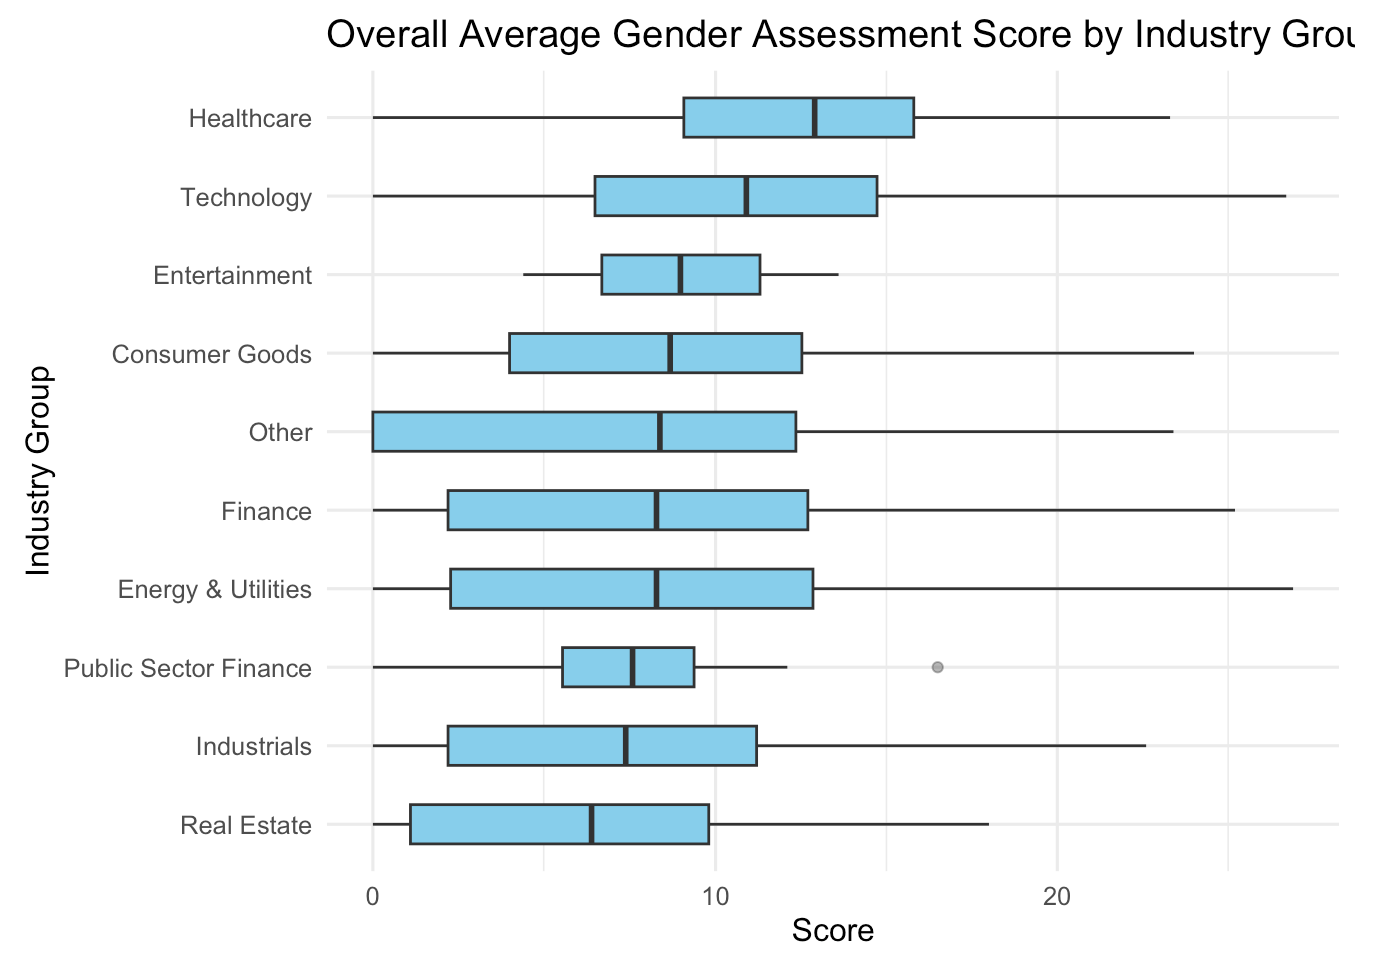